# 02 — Rating-Volatilität

Frage: *Schwanken die Ratings in einer Gruppe stärker als in der anderen?*

Kennzahl: `normalized_volatility` = Ø |rating_change| geteilt durch K-Faktor — das macht Spieler mit unterschiedlichem K vergleichbar.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from _setup import load_view, load_query, apply_style, GROUP_PALETTE, GROUP_ORDER

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

apply_style()

## Daten laden

In [2]:
df = load_view('v_rating_volatility')
df['period'] = pd.to_datetime(df['period'])
df[['avg_abs_change', 'normalized_volatility']] = (
    df[['avg_abs_change', 'normalized_volatility']].astype(float)
)
df = df.dropna(subset=['normalized_volatility'])
print(df.shape)
df.head()

(17207, 6)


,analysis_group,fide_id,period,k_factor,avg_abs_change,normalized_volatility
0,female_top,617822,2015-05-01,10.0,0.253333,0.025333
1,female_top,617822,2015-07-01,10.0,0.263636,0.026364
2,female_top,617822,2015-12-01,10.0,0.273750,0.027375
3,female_top,617822,2016-07-01,10.0,0.205000,0.020500
4,female_top,617822,2017-06-01,10.0,0.241333,0.024133


## Summary pro Gruppe

In [3]:
df.groupby('analysis_group').agg(
    n=('fide_id', 'count'),
    mean_abs_change=('avg_abs_change', 'mean'),
    mean_norm_vol=('normalized_volatility', 'mean'),
    median_norm_vol=('normalized_volatility', 'median'),
).round(3)

,n,mean_abs_change,mean_norm_vol,median_norm_vol
analysis_group,,,,
female_top,2874,0.274,0.023,0.023
male_control,14333,0.262,0.022,0.022


## Boxplot — normalisierte Volatilität

/var/folders/3b/wd_8tgyj0x3d8fgs9v_jsn1m0000gn/T/ipykernel_6540/1606667424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


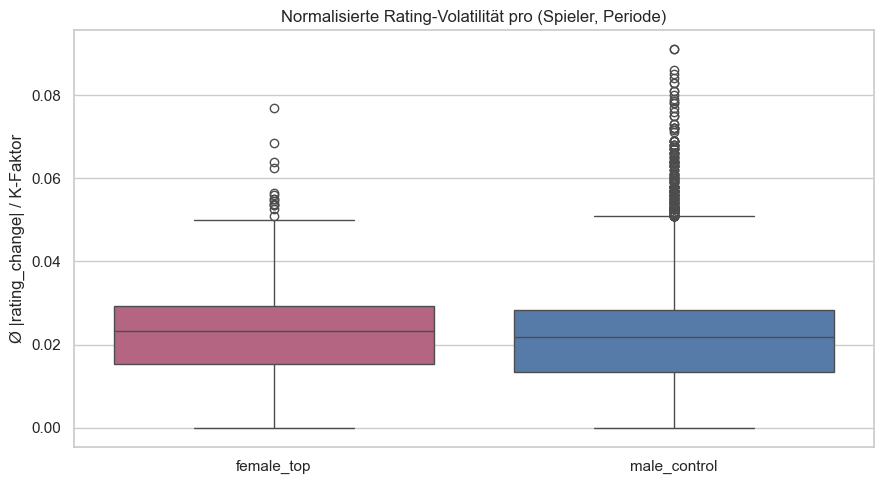

In [4]:
fig, ax = plt.subplots()
sns.boxplot(
    data=df, x='analysis_group', y='normalized_volatility',
    order=GROUP_ORDER, palette=GROUP_PALETTE, ax=ax,
)
ax.set_ylabel('Ø |rating_change| / K-Faktor')
ax.set_xlabel('')
ax.set_title('Normalisierte Rating-Volatilität pro (Spieler, Periode)')
plt.tight_layout(); plt.show()

## Volatilität über Zeit

Ø normalisierte Volatilität pro Periode und Gruppe.

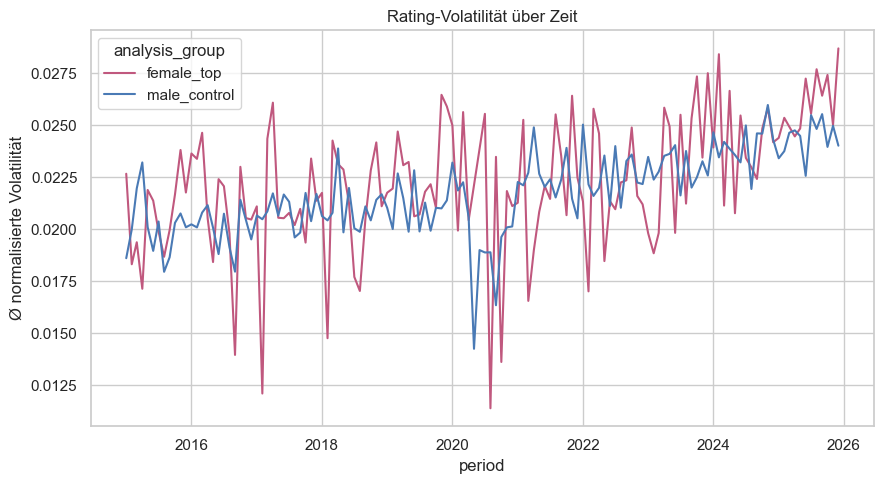

In [5]:
ts = df.groupby(['analysis_group', 'period'])['normalized_volatility'].mean().reset_index()
fig, ax = plt.subplots()
sns.lineplot(
    data=ts, x='period', y='normalized_volatility',
    hue='analysis_group', hue_order=GROUP_ORDER, palette=GROUP_PALETTE, ax=ax,
)
ax.set_ylabel('Ø normalisierte Volatilität')
ax.set_title('Rating-Volatilität über Zeit')
plt.tight_layout(); plt.show()